In [5]:
pip install pyparsing


Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
print(torch.__version__)


2.10.0+cu128


In [4]:
# ------------------------------------------------------------
# Prepare Training Images from binary sky FITS files
# Output: PyTorch Dataset + DataLoader ready for VAE training
# ------------------------------------------------------------

import os
import glob
import numpy as np
from astropy.io import fits
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
BINARY_DATA_PATH = "GRMHD_fit"   # change path if needed
IMG_SIZE = 64                    # resize target
BATCH_SIZE = 64

# ------------------------------------------------------------
# FUNCTION: load and preprocess single FITS image
# ------------------------------------------------------------
def load_fits_image(path):
    with fits.open(path) as hdul:
        img = hdul[0].data.astype(np.float32)

    # remove NaN / inf
    img = np.nan_to_num(img)

    # normalize to [0,1]
    img_min = img.min()
    img_max = img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)

    # convert to tensor
    img = torch.from_numpy(img).unsqueeze(0)  # shape (1,H,W)

    # resize to 64x64
    img = F.interpolate(
        img.unsqueeze(0),
        size=(IMG_SIZE, IMG_SIZE),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)

    return img


# ------------------------------------------------------------
# DATASET CLASS
# ------------------------------------------------------------
class BinarySkyDataset(Dataset):
    def __init__(self, root_folder):
        self.files = sorted(glob.glob(os.path.join(root_folder, "*.fits")))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = load_fits_image(self.files[idx])
        return img


# ------------------------------------------------------------
# CREATE DATASET + DATALOADER
# ------------------------------------------------------------
dataset = BinarySkyDataset(BINARY_DATA_PATH)

print("Total training images:", len(dataset))

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

# ------------------------------------------------------------
# TEST LOADING
# ------------------------------------------------------------
for batch in train_loader:
    print("Batch shape:", batch.shape)  # expected: (B,1,64,64)
    break


Total training images: 9999
Batch shape: torch.Size([64, 1, 64, 64])


In [5]:
# ------------------------------------------------------------
# Variational Autoencoder for Binary Source Images
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

LATENT_DIM = 128

# ------------------------------------------------------------
# Encoder
# ------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # 64→32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 32→16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 16→8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 8→4
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


# ------------------------------------------------------------
# Decoder
# ------------------------------------------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256*4*4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,stride=2,padding=1), #4→8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),  #8→16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),   #16→32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),    #32→64
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1,256,4,4)
        x = self.deconv(x)
        return x


# ------------------------------------------------------------
# VAE Model
# ------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE().to(device)

for batch in train_loader:
    batch = batch.to(device)
    recon, mu, logvar = model(batch)

    print("Input:", batch.shape)
    print("Recon:", recon.shape)
    print("Latent:", mu.shape)
    break


Input: torch.Size([64, 1, 64, 64])
Recon: torch.Size([64, 1, 64, 64])
Latent: torch.Size([64, 128])


In [7]:
import torch
import torch.nn.functional as F

def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss (pixel-wise)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')

    # KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)   # your VAE class
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20


In [9]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        imgs = batch.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(imgs)

        loss, r_loss, k_loss = vae_loss(recon, imgs, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}")


/home/ashutosh/anaconda3/envs/torch_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/20]  Loss: 0.0545
Epoch [2/20]  Loss: 0.0216
Epoch [3/20]  Loss: 0.0215
Epoch [4/20]  Loss: 0.0214
Epoch [5/20]  Loss: 0.0214
Epoch [6/20]  Loss: 0.0211
Epoch [7/20]  Loss: 0.0209
Epoch [8/20]  Loss: 0.0210
Epoch [9/20]  Loss: 0.0202
Epoch [10/20]  Loss: 0.0202
Epoch [11/20]  Loss: 0.0200
Epoch [12/20]  Loss: 0.0198
Epoch [13/20]  Loss: 0.0199
Epoch [14/20]  Loss: 0.0197
Epoch [15/20]  Loss: 0.0196
Epoch [16/20]  Loss: 0.0195
Epoch [17/20]  Loss: 0.0194
Epoch [18/20]  Loss: 0.0194
Epoch [19/20]  Loss: 0.0193
Epoch [20/20]  Loss: 0.0191


In [206]:
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader)).to(device)
    recon, _, _ = model(sample)

print("Original:", sample.shape)
print("Reconstructed:", recon.shape)


Original: torch.Size([64, 1, 64, 64])
Reconstructed: torch.Size([64, 1, 64, 64])


In [207]:
decoder = model.decoder
decoder.eval()

for p in decoder.parameters():
    p.requires_grad = False


In [208]:
from astropy.io import fits
import torch
import numpy as np

def load_oifits_full(file):

    with fits.open(file) as hdul:

        vis2 = hdul['OI_VIS2'].data
        t3   = hdul['OI_T3'].data

        def to_tensor(arr):
            return torch.from_numpy(
                np.ascontiguousarray(arr).astype(np.float32)
            )
        WAVELENGTH = 2.2e-6

        # ---- VIS2 ----
        vis2data = to_tensor(vis2['VIS2DATA'])
        vis2err  = to_tensor(vis2['VIS2ERR'])
        u        = to_tensor(vis2['UCOORD'])/ WAVELENGTH
        v        = to_tensor(vis2['VCOORD'])/ WAVELENGTH

        # ---- T3 ----
        t3phi = to_tensor(t3['T3PHI'])
        t3err = to_tensor(t3['T3PHIERR'])

        u1 = to_tensor(t3['U1COORD'])/ WAVELENGTH
        v1 = to_tensor(t3['V1COORD'])/ WAVELENGTH
        u2 = to_tensor(t3['U2COORD'])/ WAVELENGTH
        v2 = to_tensor(t3['V2COORD'])/ WAVELENGTH

    return vis2data, vis2err, u, v, t3phi, t3err, u1, v1, u2, v2


In [209]:
data = load_oifits_full("test_oifits/m87_grmhd_0050.oifits")

for d in data:
    print(d.shape, d.dtype)


torch.Size([300]) torch.float32
torch.Size([300]) torch.float32
torch.Size([300]) torch.float32
torch.Size([300]) torch.float32
torch.Size([400]) torch.float32
torch.Size([400]) torch.float32
torch.Size([400]) torch.float32
torch.Size([400]) torch.float32
torch.Size([400]) torch.float32
torch.Size([400]) torch.float32


In [210]:

PIXEL_SCALE_MAS = 0.5
pixel_scale_rad = PIXEL_SCALE_MAS * 4.84814e-9
f_max = 1 / (2 * pixel_scale_rad)

In [211]:
def sample_fft(image, u, v):

    fft = torch.fft.fftshift(torch.fft.fft2(image[0,0]))
    H, W = fft.shape

    f_max = 1.0 / (2.0 * pixel_scale_rad )

    u_norm = u / f_max
    v_norm = v / f_max

    grid = torch.stack([u_norm, v_norm], dim=-1)
    grid = grid.view(1,-1,1,2)

    real = fft.real.unsqueeze(0).unsqueeze(0)
    imag = fft.imag.unsqueeze(0).unsqueeze(0)

    real_sampled = F.grid_sample(real, grid, align_corners=True)
    imag_sampled = F.grid_sample(imag, grid, align_corners=True)

    vis = real_sampled.squeeze() + 1j*imag_sampled.squeeze()

    return vis


In [212]:
def synthetic_vis2(image, u, v):

    vis = sample_fft(image, u, v)
    return torch.abs(vis)**2


In [213]:
def synthetic_t3phi(image, u1, v1, u2, v2):

    V1 = sample_fft(image, u1, v1)
    V2 = sample_fft(image, u2, v2)

    u3 = -(u1 + u2)
    v3 = -(v1 + v2)

    V3 = sample_fft(image, u3, v3)

    bispectrum = V1 * V2 * torch.conj(V3)

    phase = torch.angle(bispectrum)

    return phase


In [214]:
def chi2_loss(image, data):

    vis2data, vis2err, u, v, t3phi, t3err, u1, v1, u2, v2 = data

    syn_vis2 = synthetic_vis2(image, u, v)
    syn_phi  = synthetic_t3phi(image, u1, v1, u2, v2)

    # VIS2 chi-square
    chi2_vis = torch.mean(((syn_vis2 - vis2data)/vis2err)**2)

    # Phase wrapping correction
    diff = syn_phi - t3phi
    wrapped = torch.atan2(torch.sin(diff), torch.cos(diff))

    chi2_phi = torch.mean((wrapped/t3err)**2)

    return chi2_vis + chi2_phi


In [215]:
data = load_oifits_full("test_oifits/m87_grmhd_0050.oifits")
data = [d.to(device) for d in data]

z = torch.randn(1, 128, requires_grad=True, device=device)
optimizer = torch.optim.Adam([z], lr=1e-2)

for i in range(1000):

    optimizer.zero_grad()

    img = decoder(z)

    loss = chi2_loss(img, data)

    loss.backward()
    optimizer.step()

    if i % 100 == 0:
        print(i, loss.item())


0 4.1613536122005094e+17
100 2.5261305417957376e+17
200 1.2871277392743629e+17
300 1.0165216927023104e+17
400 9.031251930592051e+16
500 8.20230348561449e+16
600 7.622326563844915e+16
700 7.190937901151027e+16
800 6.930360517315789e+16
900 6.761465652864614e+16


In [216]:
print(torch.isnan(loss))
print(torch.isinf(loss))
print(imgs.min(), imgs.max())


tensor(False)
tensor(False)
tensor(0.) tensor(0.9922)


In [217]:
z = torch.randn(1, 128, requires_grad=True, device=device)
optimizer = torch.optim.Adam([z], lr=1e-2)


In [218]:
final_image = decoder(z).detach().cpu().numpy()[0,0]


In [219]:
def gaussian_center_prior(img):

    im = img[0,0]

    H,W = im.shape

    y,x = torch.meshgrid(
        torch.arange(H,device=im.device),
        torch.arange(W,device=im.device),
        indexing='ij'
    )

    total = im.sum()+1e-8

    cx = (im*x).sum()/total
    cy = (im*y).sum()/total

    center_x = W/2
    center_y = H/2

    return ((cx-center_x)**2 + (cy-center_y)**2)*1e-3


In [220]:
def gaussian_symmetry_prior(img):

    im = img[0,0]

    flipped = torch.flip(im,[0,1])

    return torch.mean((im-flipped)**2)


In [221]:
def gaussian_smoothness_prior(img):

    im = img[0,0]

    dx = im[:,1:] - im[:,:-1]
    dy = im[1:,:] - im[:-1,:]

    return torch.mean(dx**2) + torch.mean(dy**2)


In [222]:
def gaussian_scale_prior(img):

    im = img[0,0]

    H,W = im.shape

    y,x = torch.meshgrid(
        torch.arange(H,device=im.device),
        torch.arange(W,device=im.device),
        indexing='ij'
    )

    total = im.sum()+1e-8

    cx = (im*x).sum()/total
    cy = (im*y).sum()/total

    r2 = (x-cx)**2 + (y-cy)**2

    variance = (im*r2).sum()/total

    # expected spread constraint
    return torch.relu(5-variance)*1e-4


In [223]:
def total_loss1(img,data):

    data_term = chi2_loss(img,data)

    center = gaussian_center_prior(img)
    sym    = gaussian_symmetry_prior(img)
    smooth = gaussian_smoothness_prior(img)
    scale  = gaussian_scale_prior(img)

    return (
        data_term
        + 0.05*center
        + 0.01*sym
        + 0.02*smooth
        + 0.01*scale
    )


In [224]:
from astropy.io import fits
import torch
import numpy as np

def load_ground_truth(path):

    with fits.open(path) as hdul:
        img = hdul[0].data.astype(np.float32)

    img = np.nan_to_num(img)

    img_min = img.min()
    img_max = img.max()

    if img_max > img_min:
        img = (img - img_min)/(img_max-img_min)

    img = torch.tensor(img).unsqueeze(0).unsqueeze(0)

    img = torch.nn.functional.interpolate(
        img,
        size=(64,64),
        mode='bilinear',
        align_corners=False
    )

    return img


In [225]:
import math

def compute_psnr(recon, truth):

    mse = torch.mean((recon-truth)**2).item()

    if mse == 0:
        return 100

    return 20 * math.log10(1.0/math.sqrt(mse))


In [226]:
import torch.nn.functional as F

def compute_ssim(img1,img2):

    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = F.avg_pool2d(img1,3,1,1)
    mu2 = F.avg_pool2d(img2,3,1,1)

    sigma1 = F.avg_pool2d(img1*img1,3,1,1)-mu1**2
    sigma2 = F.avg_pool2d(img2*img2,3,1,1)-mu2**2
    sigma12 = F.avg_pool2d(img1*img2,3,1,1)-mu1*mu2

    ssim = ((2*mu1*mu2+C1)*(2*sigma12+C2))/((mu1**2+mu2**2+C1)*(sigma1+sigma2+C2))

    return ssim.mean().item()


In [227]:
PIXEL_SCALE_MAS = 0.5

def measure_binary_separation(img):

    im = img[0,0]

    flat = im.view(-1)
    idx = torch.topk(flat,2).indices

    H,W = im.shape

    y = idx//W
    x = idx%W

    sep_pix = torch.norm(
        torch.tensor([x[0]-x[1],y[0]-y[1]]).float()
    )

    return sep_pix.item()*PIXEL_SCALE_MAS


In [228]:
def uv_residuals(img,data):

    vis2data,vis2err,u,v,t3phi,t3err,u1,v1,u2,v2 = data

    syn_vis2 = synthetic_vis2(img,u,v)
    syn_phi  = synthetic_t3phi(img,u1,v1,u2,v2)

    vis_res = ((syn_vis2-vis2data)/vis2err).detach().cpu()
    phi_res = ((syn_phi-t3phi)/t3err).detach().cpu()

    return vis_res,phi_res


In [229]:
def latent_uncertainty(decoder,z_opt,n_samples=50):

    imgs = []

    for _ in range(n_samples):

        z = z_opt + 0.1*torch.randn_like(z_opt)

        img = decoder(z).detach()

        imgs.append(img)

    stack = torch.stack(imgs)

    mean_img = stack.mean(0)
    std_img  = stack.std(0)

    return mean_img,std_img


In [230]:
recon = decoder(z).detach()

truth = load_ground_truth("Test/m87_grmhd_0050.fits").to(device)

psnr = compute_psnr(recon,truth)
ssim = compute_ssim(recon,truth)

sep_recon = measure_binary_separation(recon)
sep_truth = measure_binary_separation(truth)

print("PSNR:",psnr)
print("SSIM:",ssim)
print("Separation Error:",abs(sep_recon-sep_truth),"mas")

vis_res,phi_res = uv_residuals(recon,data)

mean_img,std_img = latent_uncertainty(decoder,z)


PSNR: 13.897613468226293
SSIM: 0.6166315674781799
Separation Error: 0.5 mas


In [231]:
save_iters = [0,50,100,200]

recon_history = {}

for i in range(4001):

    optimizer.zero_grad()

    img = decoder(z)

    loss = total_loss1(img,data)

    loss.backward()
    optimizer.step()

    if i in save_iters:
        recon_history[i] = img.detach().cpu()

    if i % 100 == 0:
        print(i,loss.item())


0 6.557279128041554e+17
100 2.5006861247420826e+17
200 1.4056706405302272e+17
300 1.0864429012877312e+17
400 9.36163369990226e+16
500 8.473688725153382e+16
600 7.953639482064896e+16
700 7.62269679002583e+16
800 7.385769214109286e+16
900 7.207493711586918e+16
1000 7.068530044724838e+16
1100 6.9655242735616e+16
1200 6.879815624189542e+16
1300 6.80880134642729e+16
1400 6.74133814762537e+16
1500 6.658669476105421e+16
1600 6.592907084352717e+16
1700 6.550369728253133e+16
1800 6.518044945389978e+16
1900 6.491120654404813e+16
2000 6.47042148901847e+16
2100 6.453304755853722e+16
2200 6.437688254765466e+16
2300 6.424477364859699e+16
2400 6.415201953487258e+16
2500 6.408442533956813e+16
2600 6.404049211909734e+16
2700 6.397047556223795e+16
2800 6.39077217950761e+16
2900 6.385856589437338e+16
3000 6.382141442726298e+16
3100 6.377042028055757e+16
3200 6.373679068662989e+16
3300 6.372188715011277e+16
3400 6.371638529700659e+16
3500 6.370953052920218e+16
3600 6.370764074359194e+16
3700 6.37026027469

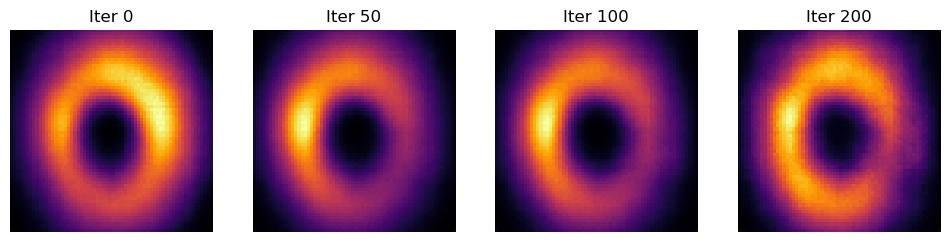

In [232]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))

for idx,step in enumerate(save_iters):

    plt.subplot(1,len(save_iters),idx+1)

    plt.imshow(
        recon_history[step][0,0],
        origin='lower',
        cmap='inferno'
    )

    plt.title(f"Iter {step}")
    plt.axis('off')

plt.show()


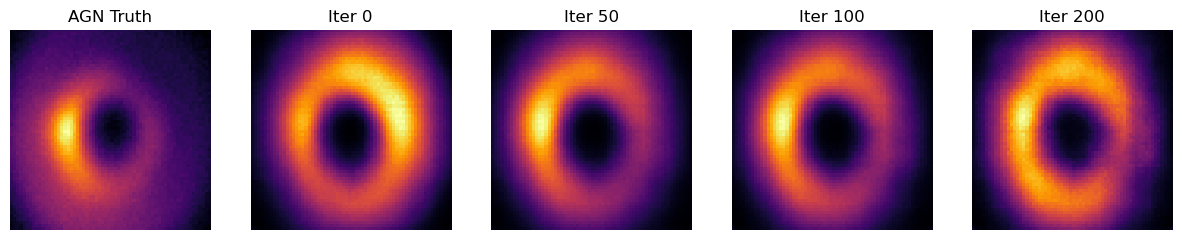

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))

# Ground truth AGN
plt.subplot(1,5,1)
plt.imshow(truth[0,0].cpu(),origin='lower',cmap='inferno')
plt.title("AGN Truth")
plt.axis('off')

# Iterative reconstructions
for idx,step in enumerate(save_iters):

    plt.subplot(1,5,idx+2)

    plt.imshow(
        recon_history[step][0,0],
        origin='lower',
        cmap='inferno'
    )

    plt.title(f"Iter {step}")
    plt.axis('off')

plt.show()


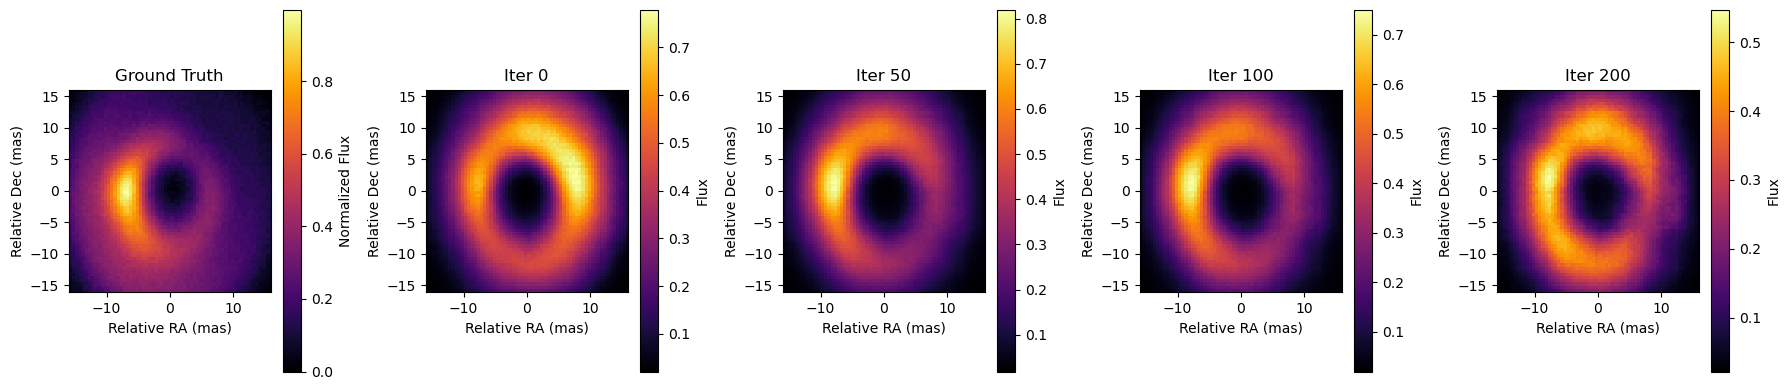

In [234]:
# ------------------------------------------------------------
# Plot reconstructed images with X/Y axes in milliarcseconds
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# USER SETTING
# ------------------------------------------------------------
PIXEL_SCALE_MAS = 0.5          # mas per pixel
IMG_SIZE = 64                 # image size
FoV_mas = IMG_SIZE * PIXEL_SCALE_MAS

# Define axis extent
extent = [
    -FoV_mas/2,   # X min
     FoV_mas/2,   # X max
    -FoV_mas/2,   # Y min
     FoV_mas/2    # Y max
]

# ------------------------------------------------------------
# Plot Ground Truth + Reconstructions
# ------------------------------------------------------------
plt.figure(figsize=(18,4))

# Ground truth
plt.subplot(1, len(save_iters)+1, 1)
plt.imshow(
    truth[0,0].cpu(),
    origin='lower',
    cmap='inferno',
    extent=extent
)
plt.title("Ground Truth")
plt.xlabel("Relative RA (mas)")
plt.ylabel("Relative Dec (mas)")
plt.colorbar(label="Normalized Flux")

# Reconstructions
for idx, step in enumerate(save_iters):

    plt.subplot(1, len(save_iters)+1, idx+2)

    plt.imshow(
        recon_history[step][0,0],
        origin='lower',
        cmap='inferno',
        extent=extent
    )

    plt.title(f"Iter {step}")
    plt.xlabel("Relative RA (mas)")
    plt.ylabel("Relative Dec (mas)")
    plt.colorbar(label="Flux")

plt.tight_layout()
plt.show()

In [201]:
def radial_profile(img):

    im = img[0,0]

    H,W = im.shape

    y,x = torch.meshgrid(
        torch.arange(H),
        torch.arange(W),
        indexing='ij'
    )

    center = torch.tensor([W/2,H/2])

    r = torch.sqrt((x-center[0])**2 + (y-center[1])**2)

    r = r.flatten().long()
    im = im.flatten()

    tbin = torch.bincount(r,weights=im)
    nr   = torch.bincount(r)

    radial = tbin/(nr+1e-8)

    return radial


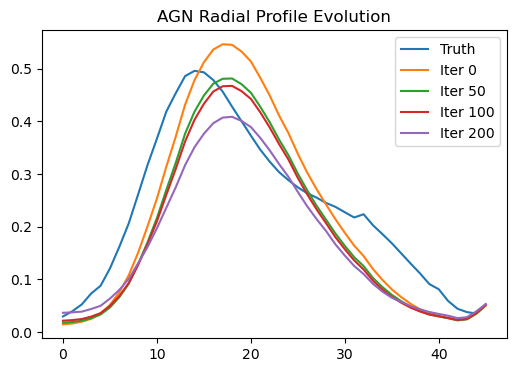

In [202]:
plt.figure(figsize=(6,4))

truth_prof = radial_profile(truth.cpu())
plt.plot(truth_prof,label='Truth')

for step in save_iters:

    prof = radial_profile(recon_history[step])
    plt.plot(prof,label=f"Iter {step}")

plt.legend()
plt.title("AGN Radial Profile Evolution")
plt.show()


In [203]:
from astropy.io import fits
import os

SAVE_DIR = "recon_fits"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_fits_image(img_tensor, filename):
    """
    img_tensor: (1,1,H,W) torch tensor
    """

    img = img_tensor.detach().cpu()

    # convert to physical image [0,1] + normalized flux
    img = (img + 1) / 2
    img = torch.clamp(img, min=1e-8)
    img = img / (img.sum(dim=(-1,-2), keepdim=True) + 1e-8)

    img_np = img[0,0].numpy()

    hdu = fits.PrimaryHDU(img_np)
    hdu.writeto(filename, overwrite=True)
    
save_iters = [10, 20, 50, 100]

for step in save_iters:
    img = recon_history[step]

    filename = os.path.join(
        SAVE_DIR,
        f"reconstruction_iter_{step}.fits"
    )

    save_fits_image(img, filename)

    print(f"Saved: {filename}")    

KeyError: 10

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

vis2data, vis2err, u, v, t3phi, t3err, u1, v1, u2, v2 = data


vis2_np = vis2data.detach().cpu().numpy()
u_np = u.detach().cpu().numpy()
v_np = v.detach().cpu().numpy()


VISAMP = np.sqrt(np.abs(vis2_np))   # |V|

baseline = np.sqrt(u_np**2 + v_np**2)

idx = np.argsort(baseline)

baseline = baseline[idx]
VISAMP = VISAMP[idx]



plt.figure(figsize=(6,4))

plt.scatter(baseline, VISAMP, s=10)

plt.xlabel("Baseline (spatial frequency)")
plt.ylabel("Visibility Amplitude |V|")
plt.title("Visibility Amplitude (Pipeline Data)")

plt.grid()
plt.show()